# 🧹 Task 1: Handling Missing Data

## 📊 Dataset: Titanic - Machine Learning from Disaster

## 📌 Introduction
This task focuses on identifying and handling missing values in the dataset. Missing data is common in real-world datasets and must be handled before model training.

## ⚙️ Techniques Used
- Mean Imputation  
- Median Imputation  
- Mode Imputation  
- Dropping Columns  
- Dropping Rows  

## ❓ Why This Matters
Different imputation techniques impact model performance and data distribution.

In [5]:
import pandas as pd

df = pd.read_csv('/kaggle/input/datasets/heptapod/titanic/train_and_test2.csv')

# Check missing values
df.isnull().sum()

# Mean Imputation
df['Age_mean'] = df['Age'].fillna(df['Age'].mean())

# Median Imputation
df['Age_median'] = df['Age'].fillna(df['Age'].median())

# Mode Imputation (categorical)
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Drop column with too many missing values
df = df.drop(columns=['Cabin'], errors='ignore')

# Drop rows (alternative strategy)
df_drop_rows = df.dropna()

## 📈 Results & Observations
- Median imputation is more robust for skewed data  
- Mode works best for categorical variables  
- Dropping Cabin is reasonable due to excessive missing values  
- Dropping rows reduces dataset size significantly  

# 🔢 Task 2: Feature Encoding

## 📊 Dataset: Car Evaluation

## 📌 Introduction
Categorical variables are converted into numerical form for machine learning models.

## ⚙️ Techniques
- Label Encoding  
- One-Hot Encoding  

## ❓ Why
- Models require numerical input  
- Encoding affects interpretation  

In [8]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

df = pd.read_csv('/kaggle/input/datasets/elikplim/car-evaluation-data-set/car_evaluation.csv')

# Label Encoding
le = LabelEncoder()
for col in df.columns:
    df[col] = le.fit_transform(df[col])

# One-Hot Encoding
df_onehot = pd.get_dummies(df)

## 📈 Results & Observations
- Label encoding introduces ordering  
- One-hot avoids false relationships  
- One-hot increases dimensionality  

# 📏 Task 3: Feature Scaling

## 📊 Dataset: Wine Quality

## 📌 Introduction
Scaling ensures all features contribute equally.

## ⚙️ Techniques
- Standardization  
- Normalization  

## ❓ Why
Distance-based models are sensitive to scale.

In [12]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import numpy as np

df = pd.read_csv('/kaggle/input/datasets/rajyellow46/wine-quality/winequalityN.csv')

# Select only numeric columns
X_numeric = X.select_dtypes(include=np.number)

# Standardization
scaler_std = StandardScaler()
X_std = scaler_std.fit_transform(X_numeric)

# Normalization
scaler_mm = MinMaxScaler()
X_norm = scaler_mm.fit_transform(X_numeric)

## 📈 Results & Observations
- Standardization centers data around 0  
- Normalization scales between 0 and 1  
- Distribution shape remains but spread changes  

# 📉 Task 4: Handling Outliers

## 📊 Dataset: Boston Housing

## 📌 Introduction
Outliers can negatively affect model performance.

## ⚙️ Techniques
- Z-score  
- IQR  

## ❓ Why
Helps detect extreme values.

In [15]:
import numpy as np
import pandas as pd
from scipy import stats

df = pd.read_csv('/kaggle/input/datasets/schirmerchad/bostonhoustingmlnd/housing.csv')

# Z-score
z = np.abs(stats.zscore(df))
df_z = df[(z < 3).all(axis=1)]

# IQR
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1
df_iqr = df[~((df < (Q1 - 1.5*IQR)) | (df > (Q3 + 1.5*IQR))).any(axis=1)]

## 📈 Results & Observations
- Z-score works for normal distributions  
- IQR works better for skewed data  
- IQR preserves more valid data  

## 🧠 Task 5: Advanced Imputation

### 📊 Dataset: Retail Sales

### 📌 Introduction
This task applies advanced methods to handle missing values using relationships between features.

### ⚙️ Techniques Used
- KNN Imputer  
- MICE (Iterative Imputer)  

### ❓ Why This Matters
Advanced techniques provide more accurate imputations by considering feature relationships.


In [17]:
from sklearn.impute import KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
import pandas as pd

df = pd.read_csv('/kaggle/input/datasets/teenasapra/retails-sales-data/retail_sales_data.csv')

# Separate numeric & non-numeric
df_numeric = df.select_dtypes(include=np.number)
df_categorical = df.select_dtypes(exclude=np.number)

# Apply KNN
knn = KNNImputer(n_neighbors=5)
df_knn_numeric = pd.DataFrame(
    knn.fit_transform(df_numeric),
    columns=df_numeric.columns
)

# Combine back
df_knn_final = pd.concat([df_knn_numeric, df_categorical.reset_index(drop=True)], axis=1)

### 📈 Results & Observations
- KNN fills values based on similar data points  
- MICE models each feature iteratively  
- MICE is more accurate but computationally expensive  

## 🏗️ Task 6: Feature Engineering

### 📊 Dataset: Heart Disease

### 📌 Introduction
New features are created to improve model performance.

### ⚙️ Techniques Used
- Age grouping  
- Cholesterol categorization  
- Risk score creation  

### ❓ Why This Matters
Derived features capture domain knowledge and improve model understanding.


In [18]:
import pandas as pd

df = pd.read_csv('/kaggle/input/datasets/johnsmith88/heart-disease-dataset/heart.csv')

df['Age_Group'] = pd.cut(df['age'], bins=[0,30,50,100], labels=['Young','Middle','Old'])
df['Chol_Category'] = pd.cut(df['chol'], bins=[0,200,240,600], labels=['Normal','Borderline','High'])
df['Risk_Score'] = df['chol'] + df['thalach']

### 📈 Results & Observations
- Binned features improve interpretability  
- Combined features capture relationships  

## 🔄 Task 7: Variable Transformation

### 📊 Dataset: Bike Sharing

### 📌 Introduction
Transformations are applied to reduce skewness in data.

### ⚙️ Techniques Used
- Log Transformation  
- Square Root Transformation  
- Box-Cox Transformation  

### ❓ Why This Matters
Transformations stabilize variance and improve model performance.


In [19]:
import numpy as np
from scipy.stats import boxcox

df = pd.read_csv('/kaggle/input/datasets/yasserh/bike-sharing-dataset/day.csv')

df['cnt_log'] = np.log1p(df['cnt'])
df['cnt_sqrt'] = np.sqrt(df['cnt'])
df['cnt_boxcox'], _ = boxcox(df['cnt'] + 1)

### 📈 Results & Observations
- Log transformation reduces right skew  
- Box-Cox produces near-normal distribution  

## 🎯 Task 8: Feature Selection

### 📊 Dataset: Pima Indians Diabetes

### 📌 Introduction
This task identifies the most important features for prediction.

### ⚙️ Techniques Used
- Correlation Analysis  
- Mutual Information  
- Recursive Feature Elimination (RFE)  

### ❓ Why This Matters
Reduces dimensionality and improves model efficiency.


In [20]:
from sklearn.feature_selection import mutual_info_classif, RFE
from sklearn.linear_model import LogisticRegression
import pandas as pd

df = pd.read_csv('/kaggle/input/datasets/organizations/uciml/pima-indians-diabetes-database/diabetes.csv')

X = df.drop('Outcome', axis=1)
y = df['Outcome']

mi = mutual_info_classif(X, y)

model = LogisticRegression(max_iter=1000)
rfe = RFE(model, n_features_to_select=5)
rfe.fit(X, y)

RFE(estimator=LogisticRegression(max_iter=1000), n_features_to_select=5)

### 📈 Results & Observations
- Correlation identifies linear relationships  
- Mutual information captures nonlinear relationships  
- RFE selects optimal feature subset  

## ⚖️ Task 9: Imbalanced Data

### 📊 Dataset: Credit Card Fraud Detection

### 📌 Introduction
This dataset contains highly imbalanced classes.

### ⚙️ Techniques Used
- SMOTE  
- ADASYN  
- Undersampling  

### ❓ Why This Matters
Balancing data improves model performance on minority class.



In [21]:
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler
import pandas as pd

df = pd.read_csv('/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv')

X = df.drop('Class', axis=1)
y = df['Class']

smote = SMOTE()
X_sm, y_sm = smote.fit_resample(X, y)

adasyn = ADASYN()
X_ad, y_ad = adasyn.fit_resample(X, y)

under = RandomUnderSampler()
X_un, y_un = under.fit_resample(X, y)

### 📈 Results & Observations
- SMOTE generates synthetic samples  
- ADASYN focuses on difficult samples  
- Undersampling reduces dataset size  

## 🔗 Task 10: Combining Datasets

### 📊 Dataset: MovieLens

### 📌 Introduction
This task merges multiple datasets to enrich information.

### ⚙️ Techniques Used
- Dataset merging (join operation)  
- Feature extraction  
- Data cleaning  

### ❓ Why This Matters
Combining datasets improves context and enables advanced applications.



In [23]:
import pandas as pd

# Load datasets
ratings = pd.read_csv('/kaggle/input/datasets/aigamer/movie-lens-dataset/ratings.csv')
movies = pd.read_csv('/kaggle/input/datasets/aigamer/movie-lens-dataset/movies.csv')

# Inspect columns
print("Ratings Columns:", ratings.columns)
print("Movies Columns:", movies.columns)


# Merge on common key 'movieId'
df = ratings.merge(movies, on='movieId', how='inner')

df.head()


# Convert UNIX timestamp to readable datetime
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='s')


# Extract release year
df['release_year'] = df['title'].str.extract(r'\((\d{4})\)')

# Convert to numeric
df['release_year'] = pd.to_numeric(df['release_year'], errors='coerce')

df['clean_title'] = df['title'].str.replace(r'\(\d{4}\)', '', regex=True).str.strip()

# Split genres into list
df['genres'] = df['genres'].str.split('|')

Ratings Columns: Index(['userId', 'movieId', 'rating', 'timestamp'], dtype='object')
Movies Columns: Index(['movieId', 'title', 'genres'], dtype='object')


### 📈 Results & Observations
- Successfully merged ratings and movie data  
- Extracted temporal and textual features  
- Prepared dataset for recommendation systems  

## 📉 Task 11: Dimensionality Reduction

### 📊 Dataset: MNIST

### 📌 Introduction
High-dimensional data is reduced while preserving structure.

### ⚙️ Techniques Used
- PCA  
- t-SNE  

### ❓ Why This Matters
Reduces computational complexity and helps visualization.



/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


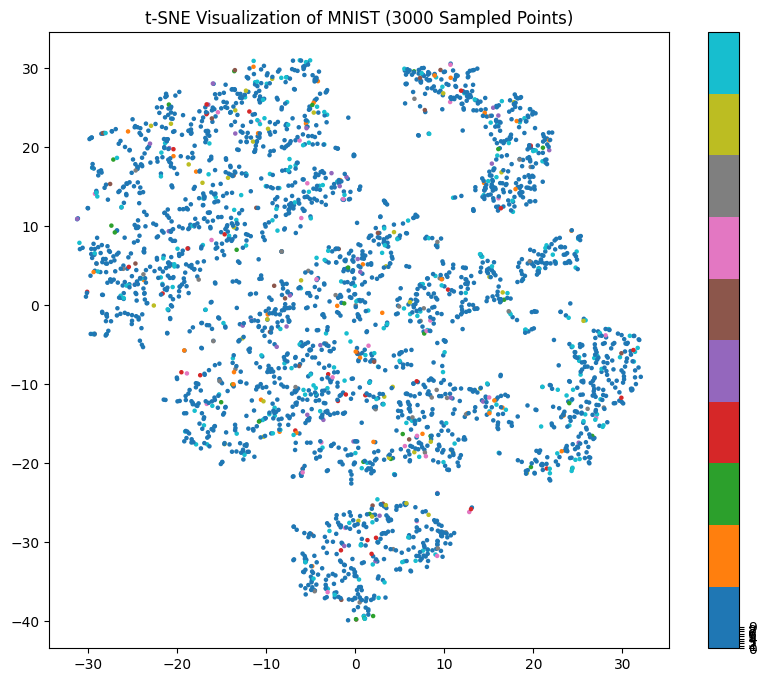

In [35]:
# MNIST PCA + t-SNE Visualization from CSV

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# -----------------------------
# 1. Load MNIST CSV train split
# -----------------------------
X_train = pd.read_csv('/kaggle/input/datasets/oddrationale/mnist-in-csv/mnist_train.csv').values  # change path if needed
y_train = pd.read_csv('/kaggle/input/datasets/oddrationale/mnist-in-csv/mnist_train.csv').values.ravel()  # flatten to 1D

# Optional: Load test set if needed
# X_test = pd.read_csv('/kaggle/input/mnist/X_test.csv').values
# y_test = pd.read_csv('/kaggle/input/mnist/y_test.csv').values.ravel()

# -----------------------------
# 2. Scale the features
# -----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

# -----------------------------
# 3. Sample for speed (t-SNE is slow)
# -----------------------------
max_samples = 3000
idx = np.random.choice(len(X_scaled), max_samples, replace=False)
X_sample = X_scaled[idx]
y_sample = y_train[idx]

# -----------------------------
# 4. PCA to reduce dimensions before t-SNE
# -----------------------------
pca = PCA(n_components=50, random_state=42)
X_pca = pca.fit_transform(X_sample)

# -----------------------------
# 5. t-SNE to 2D
# -----------------------------
tsne = TSNE(n_components=2, n_iter=500, init='pca', random_state=42)
X_tsne = tsne.fit_transform(X_pca)

# -----------------------------
# 6. Visualization
# -----------------------------
plt.figure(figsize=(10,8))
scatter = plt.scatter(X_tsne[:,0], X_tsne[:,1], c=y_sample, cmap='tab10', s=5)
plt.colorbar(scatter, ticks=range(10))
plt.title("t-SNE Visualization of MNIST (3000 Sampled Points)")
plt.show()

### 📈 Results & Observations
- PCA reduces dimensions efficiently  
- t-SNE visualizes clusters effectively  

## 📝 Task 12: Text Preprocessing

### 📊 Dataset: IMDB Reviews

### 📌 Introduction
Text data is cleaned and prepared for NLP tasks.

### ⚙️ Steps Performed
- Lowercasing  
- Stopword removal  
- Stemming  
- Tokenization  

### ❓ Why This Matters
Cleaning text improves model accuracy and efficiency.



In [38]:
import pandas as pd
import re
from nltk.stem import PorterStemmer

# 1️⃣ Load your CSV
df = pd.read_csv('/kaggle/input/datasets/vishakhdapat/imdb-movie-reviews/IMDB Dataset.csv')  # replace with your CSV path

# 2️⃣ Check columns
print("Columns in CSV:", df.columns)

# Most IMDB CSVs have 'review' and 'sentiment'
text_col = 'review'  # replace with the correct column name after checking

# 3️⃣ Offline stopwords list
stop_words = {
    'i','me','my','myself','we','our','ours','ourselves','you',
    "you're","you've","you'll","you'd",'your','yours','yourself',
    'yourselves','he','him','his','himself','she',"she's",'her',
    'hers','herself','it',"it's",'its','itself','they','them',
    'their','theirs','themselves','what','which','who','whom',
    'this','that',"that'll",'these','those','am','is','are','was',
    'were','be','been','being','have','has','had','having','do',
    'does','did','doing','a','an','the','and','but','if','or',
    'because','as','until','while','of','at','by','for','with',
    'about','against','between','into','through','during','before',
    'after','above','below','to','from','up','down','in','out','on',
    'off','over','under','again','further','then','once','here','there',
    'when','where','why','how','all','any','both','each','few','more',
    'most','other','some','such','no','nor','not','only','own','same',
    'so','than','too','very','s','t','can','will','just','don',"don't",
    'should',"should've",'now','d','ll','m','o','re','ve','y','ain',
    'aren',"aren't",'couldn',"couldn't",'didn',"didn't",'doesn',
    "doesn't",'hadn',"hadn't",'hasn',"hasn't",'haven',"haven't",
    'isn',"isn't",'ma','mightn',"mightn't",'mustn',"mustn't",
    'needn',"needn't",'shan',"shan't",'shouldn',"shouldn't",
    'wasn',"wasn't",'weren',"weren't",'won',"won't",'wouldn',"wouldn't"
}

# 4️⃣ Stemming
ps = PorterStemmer()

# 5️⃣ Text preprocessing: lowercase, remove punctuation, remove stopwords, stem
df['clean'] = df[text_col].str.lower()  # lowercase
df['clean'] = df['clean'].apply(lambda x: re.sub(r'[^a-z\s]', '', x))  # remove punctuation
df['clean'] = df['clean'].apply(lambda x: ' '.join([word for word in x.split() if word not in stop_words]))  # remove stopwords
df['clean'] = df['clean'].apply(lambda x: ' '.join([ps.stem(word) for word in x.split()]))  # stemming

# 6️⃣ Check results
print(df[['review','clean']].head())

Columns in CSV: Index(['review', 'sentiment'], dtype='object')
                                              review  \
0  One of the other reviewers has mentioned that ...   
1  A wonderful little production. <br /><br />The...   
2  I thought this was a wonderful way to spend ti...   
3  Basically there's a family where a little boy ...   
4  Petter Mattei's "Love in the Time of Money" is...   

                                               clean  
0  one review mention watch oz episod youll hook ...  
1  wonder littl product br br film techniqu unass...  
2  thought wonder way spend time hot summer weeke...  
3  basic there famili littl boy jake think there ...  
4  petter mattei love time money visual stun film...  


### 📈 Results & Observations
- Noise reduced  
- Vocabulary size decreased  
- Better model performance  

## ⏱️ Task 13: Time-Series Preprocessing

### 📊 Dataset: Air Quality

### 📌 Introduction
Time-based data is processed for analysis.

### ⚙️ Techniques Used
- Datetime conversion  
- Resampling  
- Rolling averages  

### ❓ Why This Matters
Helps analyze trends and smooth fluctuations.



In [2]:
import pandas as pd

# Load CSV
df = pd.read_csv('/kaggle/input/datasets/fedesoriano/air-quality-data-set/AirQuality.csv', sep=';')
print("Columns in CSV:", df.columns)

# Fix Time column format: '18.00.00' -> '18:00:00'
df['Time'] = df['Time'].str.replace('.', ':', regex=False)

# Combine Date and Time
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], dayfirst=True, errors='coerce')

# Drop rows where datetime could not be parsed
df = df.dropna(subset=['Datetime'])

# Set datetime as index
df.set_index('Datetime', inplace=True)

# Keep only numeric columns for resampling
numeric_cols = df.select_dtypes(include='number').columns
df_numeric = df[numeric_cols]

# Resample daily and compute mean
df_resampled = df_numeric.resample('D').mean()

# Compute 7-day rolling mean for 'CO(GT)' if exists
if 'CO(GT)' in df_numeric.columns:
    df_numeric['Rolling'] = df_numeric['CO(GT)'].rolling(7).mean()

# Inspect results
print(df_numeric.head())
print(df_resampled.head())

Columns in CSV: Index(['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)',
       'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)',
       'PT08.S5(O3)', 'T', 'RH', 'AH', 'Unnamed: 15', 'Unnamed: 16'],
      dtype='object')
                     PT08.S1(CO)  NMHC(GT)  PT08.S2(NMHC)  NOx(GT)  \
Datetime                                                             
2004-03-10 18:00:00       1360.0     150.0         1046.0    166.0   
2004-03-10 19:00:00       1292.0     112.0          955.0    103.0   
2004-03-10 20:00:00       1402.0      88.0          939.0    131.0   
2004-03-10 21:00:00       1376.0      80.0          948.0    172.0   
2004-03-10 22:00:00       1272.0      51.0          836.0    131.0   

                     PT08.S3(NOx)  NO2(GT)  PT08.S4(NO2)  PT08.S5(O3)  \
Datetime                                                                
2004-03-10 18:00:00        1056.0    113.0        1692.0       1268.0   
2004-03-10 19:00:00        1174.

### 📈 Results & Observations
- Resampling standardizes time intervals  
- Rolling averages reduce noise  